In [25]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print(fonts)  # ['NanumGothic', 'NanumBarunGothic', ...] 나오면 정상

['NanumSquare', 'NanumBarunGothic', 'NanumMyeongjo', 'NanumGothic', 'NanumMyeongjo', 'NanumBarunGothic', 'NanumGothicCoding', 'NanumGothic', 'NanumSquare', 'NanumSquareRound', 'NanumSquareRound', 'NanumGothicCoding']


## 데이터 합치기

In [26]:
import pandas as pd

df1 = pd.read_csv('data/rent1.csv', encoding='cp949', skiprows=15)
df2 = pd.read_csv('data/rent2.csv', encoding='cp949', skiprows=15)

print('rent1:', df1.shape)
print('rent2:', df2.shape)

df1.head(3)
df2.head(3)

rent1: (540, 18)
rent2: (333, 18)


,NO,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세금(만원),건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형
0,1,인천광역시 미추홀구 용현동,3*,25m이상,23.00,월세,202504,19,300,35,1998.0,인하로,202504~202604,신규,-,NaN,NaN,단독다가구
1,2,인천광역시 미추홀구 용현동,3*,25m이상,42.31,월세,202504,18,500,40,1978.0,인하로,202505~202705,신규,-,NaN,NaN,단독다가구
2,3,인천광역시 미추홀구 용현동,*,12m미만,31.55,월세,202504,18,300,30,1993.0,인하로163번길,202505~202705,신규,-,NaN,NaN,단독다가구


In [27]:
df = pd.concat([df1, df2], ignore_index=True)
print('합친 데이터:', df.shape)
df.head()
df.to_csv('data/rent_merged.csv', index=False, encoding='utf-8-sig')
print('저장 완료: data/rent_merged.csv')

합친 데이터: (873, 18)
저장 완료: data/rent_merged.csv


## 데이터 분석

In [28]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
for fname in fm.findSystemFonts():
    try:
        f = fm.FontProperties(fname=fname)
        if any(k in f.get_name() for k in ['Nanum', 'Gothic', 'Malgun', 'AppleGothic']):
            plt.rcParams['font.family'] = f.get_name()
            break
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 숫자형 변환 (보증금, 월세 컬럼에 쉼표 제거)
for col in ['보증금(만원)', '월세금(만원)', '종전계약 보증금(만원)', '종전계약 월세(만원)']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '').replace('nan', float('nan'))
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['계약면적(㎡)'] = pd.to_numeric(df['계약면적(㎡)'], errors='coerce')
df['건축년도'] = pd.to_numeric(df['건축년도'], errors='coerce')

TARGET = '월세금(만원)'
print("전처리 완료. 타겟 변수:", TARGET)

전처리 완료. 타겟 변수: 월세금(만원)


## STEP 1: 기본 현황 파악

In [29]:
print(f"샘플 수: {df.shape[0]:,}개  |  변수 수: {df.shape[1]}개")
print(f"\n[컬럼 목록]\n{df.columns.tolist()}")
print("\n[데이터 타입]")
print(df.dtypes)
df.head(3)

샘플 수: 873개  |  변수 수: 18개

[컬럼 목록]
['NO', '시군구', '번지', '도로조건', '계약면적(㎡)', '전월세구분', '계약년월', '계약일', '보증금(만원)', '월세금(만원)', '건축년도', '도로명', '계약기간', '계약구분', '갱신요구권 사용', '종전계약 보증금(만원)', '종전계약 월세(만원)', '주택유형']

[데이터 타입]
NO                int64
시군구                 str
번지                  str
도로조건                str
계약면적(㎡)         float64
전월세구분               str
계약년월              int64
계약일               int64
보증금(만원)           int64
월세금(만원)           int64
건축년도            float64
도로명                 str
계약기간                str
계약구분                str
갱신요구권 사용            str
종전계약 보증금(만원)    float64
종전계약 월세(만원)     float64
주택유형                str
dtype: object


,NO,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세금(만원),건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형
0,1,인천광역시 미추홀구 용현동,5**,25m미만,23.0,월세,202604,11,500,45,2021.0,능해길,202604~202704,신규,-,NaN,NaN,단독다가구
1,2,인천광역시 미추홀구 용현동,4*,8m미만,17.0,월세,202604,6,300,45,NaN,한나루로463번길,202604~202612,신규,-,NaN,NaN,단독다가구
2,3,인천광역시 미추홀구 용현동,6**,8m미만,20.0,월세,202604,4,300,45,2016.0,낙섬서로10번길,202604~202704,신규,-,NaN,NaN,단독다가구


In [30]:
print("[결측치 현황]")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '결측 비율(%)': missing_pct})
display(missing_df[missing_df['결측치 수'] > 0])

print("\n[기본 통계]")
display(df.describe())

[결측치 현황]


,결측치 수,결측 비율(%)
건축년도,71,8.13
도로명,1,0.11
종전계약 보증금(만원),846,96.91
종전계약 월세(만원),846,96.91



[기본 통계]


,NO,계약면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),건축년도,종전계약 보증금(만원),종전계약 월세(만원)
count,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,802.000000,27.000000,27.000000
mean,231.020619,28.089507,202506.013746,15.895762,1149.720504,35.780069,2002.630923,5437.074074,12.592593
std,145.283650,11.900230,66.661267,8.640071,2085.035857,16.846779,11.816573,4958.340642,18.731420
min,1.000000,13.000000,202404.000000,1.000000,0.000000,0.000000,1956.000000,276.000000,0.000000
25%,110.000000,20.000000,202501.000000,9.000000,300.000000,30.000000,1996.000000,400.000000,0.000000
50%,219.000000,23.100000,202507.000000,16.000000,300.000000,38.000000,2002.000000,4000.000000,0.000000
75%,328.000000,33.210000,202512.000000,23.000000,500.000000,45.000000,2015.000000,8750.000000,27.000000
max,540.000000,60.000000,202604.000000,31.000000,15900.000000,90.000000,2022.000000,15900.000000,55.000000


## STEP 2: 타겟 변수 및 Feature 분포 시각화

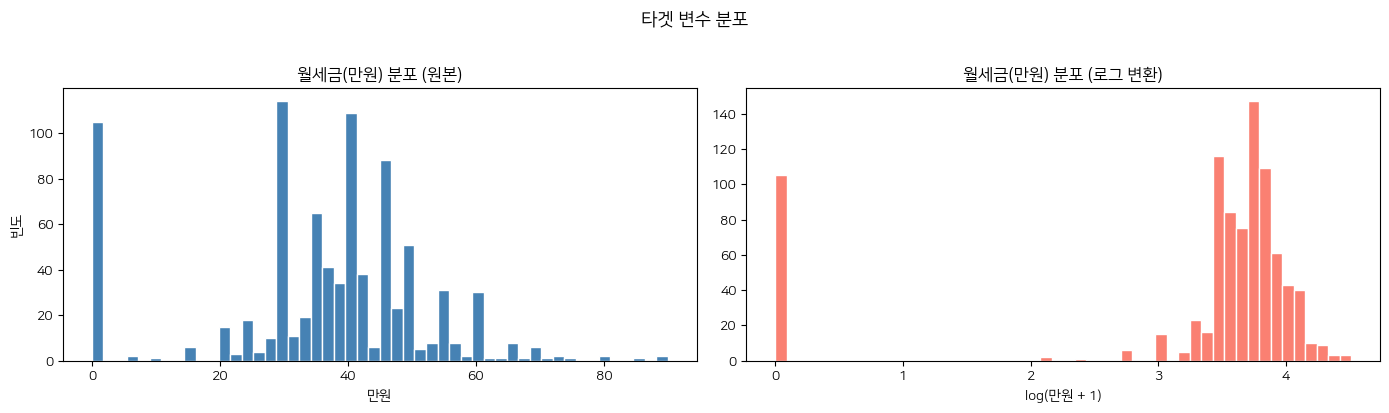


월세금 통계:
count    873.000000
mean      35.780069
std       16.846779
min        0.000000
25%       30.000000
50%       38.000000
75%       45.000000
max       90.000000
Name: 월세금(만원), dtype: float64


In [31]:
# 타겟 변수 (월세금) 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, edgecolor='white', color='steelblue')
axes[0].set_title(f'{TARGET} 분포 (원본)')
axes[0].set_xlabel('만원')
axes[0].set_ylabel('빈도')

import numpy as np
log_vals = np.log1p(df[TARGET].dropna())
axes[1].hist(log_vals, bins=50, edgecolor='white', color='salmon')
axes[1].set_title(f'{TARGET} 분포 (로그 변환)')
axes[1].set_xlabel('log(만원 + 1)')

plt.suptitle('타겟 변수 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n월세금 통계:\n{df[TARGET].describe()}")

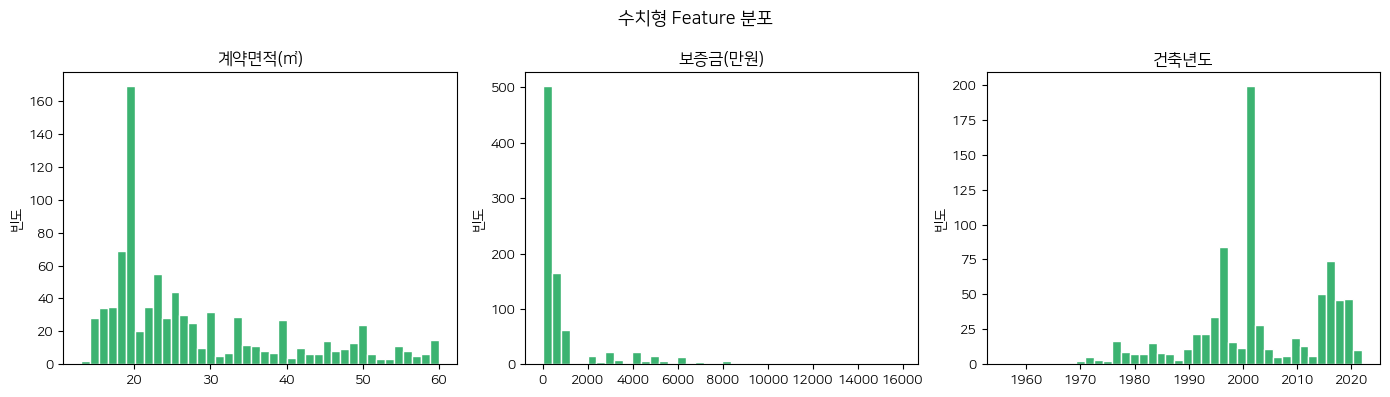

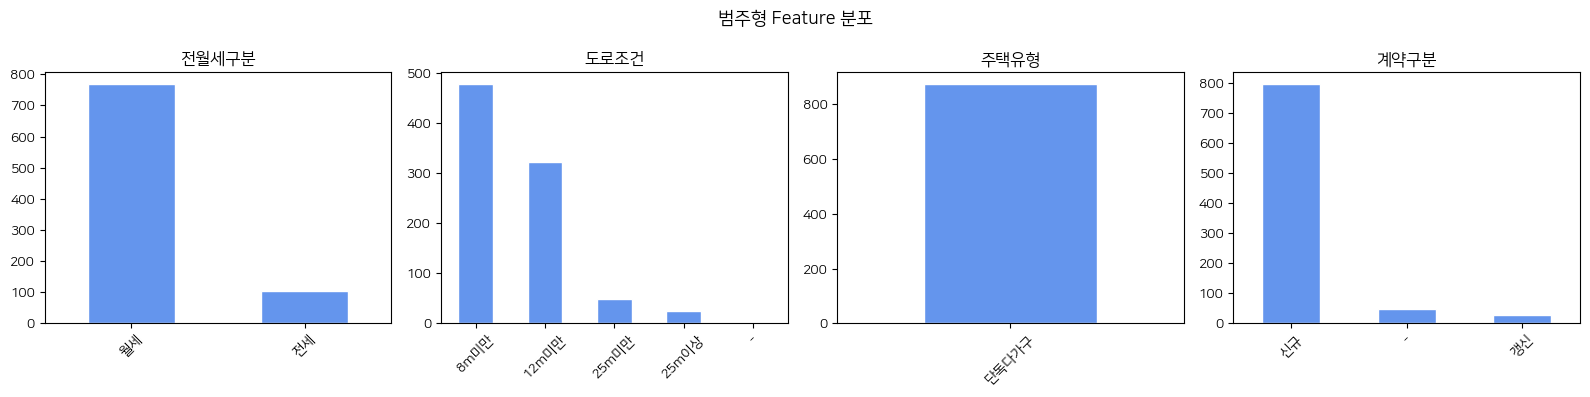

In [32]:
# 수치형 feature 분포 (타겟 제외)
num_cols = ['계약면적(㎡)', '보증금(만원)', '건축년도']
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=40, edgecolor='white', color='mediumseagreen')
    ax.set_title(col)
    ax.set_ylabel('빈도')
plt.suptitle('수치형 Feature 분포', fontsize=13)
plt.tight_layout()
plt.show()

# 범주형 feature 분포 (상위 10개)
cat_cols = ['전월세구분', '도로조건', '주택유형', '계약구분']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts().head(10)
    vc.plot(kind='bar', ax=ax, color='cornflowerblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('범주형 Feature 분포', fontsize=13)
plt.tight_layout()
plt.show()

## STEP 3: Feature와 타겟 변수 간의 관계 분석

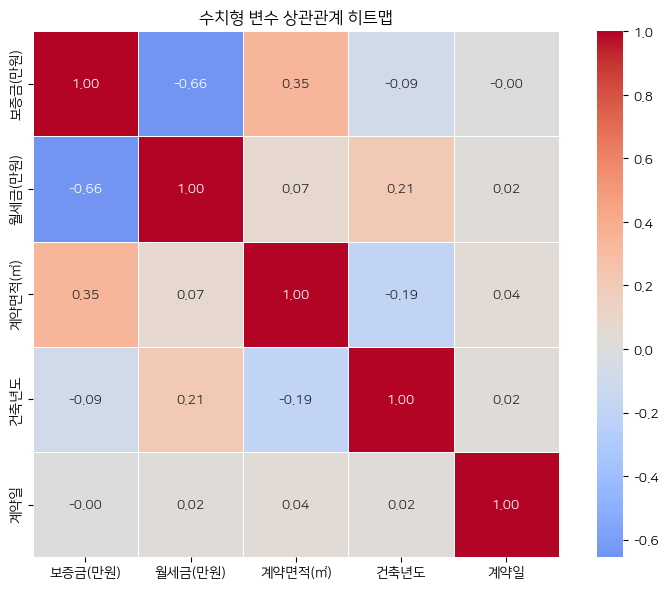


타겟(보증금)과의 상관계수:
건축년도       0.212058
계약면적(㎡)    0.070689
계약일        0.020697
보증금(만원)   -0.655224
Name: 월세금(만원), dtype: float64


In [33]:
# 수치형 변수 상관관계 히트맵
num_df = df[['보증금(만원)', '월세금(만원)', '계약면적(㎡)', '건축년도', '계약일']].dropna()
corr = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('수치형 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

print("\n타겟(보증금)과의 상관계수:")
print(corr[TARGET].drop(TARGET).sort_values(ascending=False))

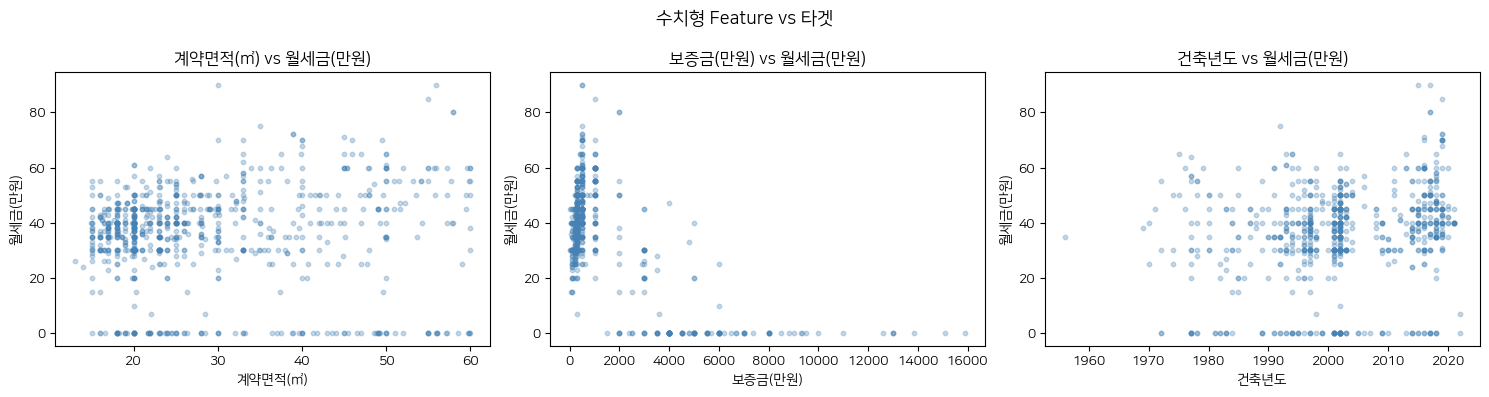

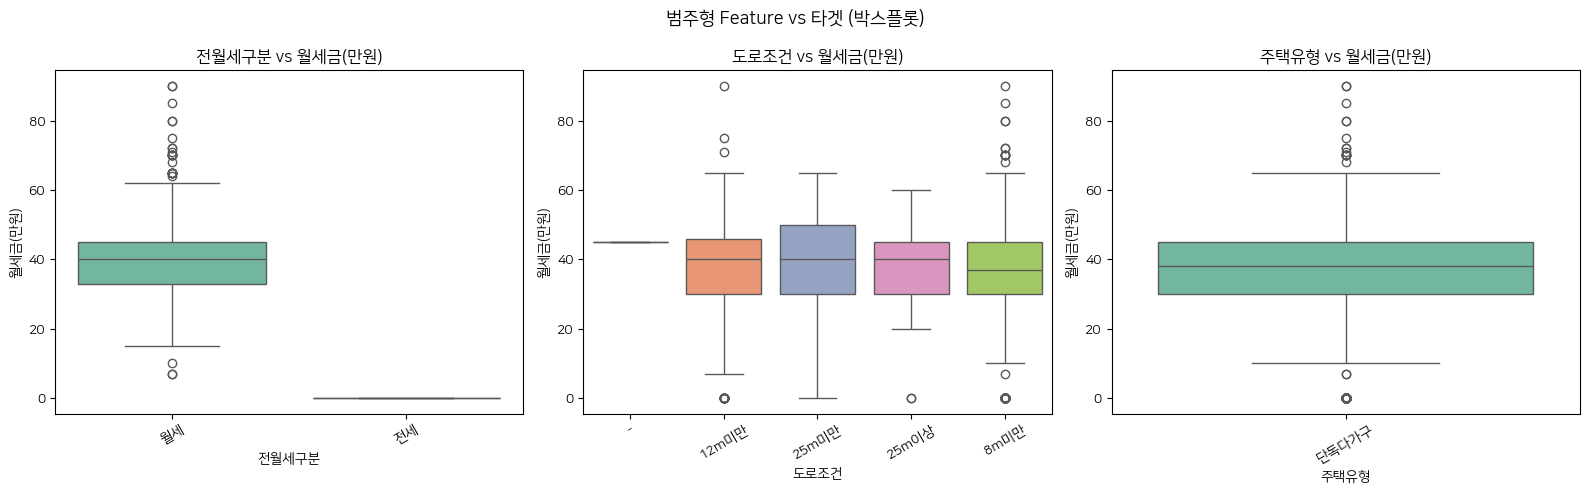

In [34]:
# 수치형 feature vs 타겟 산점도
scatter_cols = ['계약면적(㎡)', '보증금(만원)', '건축년도']
fig, axes = plt.subplots(1, len(scatter_cols), figsize=(15, 4))
for ax, col in zip(axes, scatter_cols):
    ax.scatter(df[col], df[TARGET], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.set_title(f'{col} vs {TARGET}')
plt.suptitle('수치형 Feature vs 타겟', fontsize=13)
plt.tight_layout()
plt.show()

# 범주형 feature vs 타겟 박스플롯
box_cols = ['전월세구분', '도로조건', '주택유형']
fig, axes = plt.subplots(1, len(box_cols), figsize=(16, 5))
for ax, col in zip(axes, box_cols):
    order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs {TARGET}')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('범주형 Feature vs 타겟 (박스플롯)', fontsize=13)
plt.tight_layout()
plt.show()

## STEP 4: 이상치 탐지

[IQR 기반 이상치 현황]


,Q1,Q3,하한,상한,이상치 수,이상치 비율(%)
컬럼,,,,,,
보증금(만원),300.0,500.00,0.000,800.000,205,23.48
월세금(만원),30.0,45.00,7.500,67.500,123,14.09
계약면적(㎡),20.0,33.21,0.185,53.025,48,5.50
건축년도,1996.0,2015.00,1967.500,2043.500,1,0.11


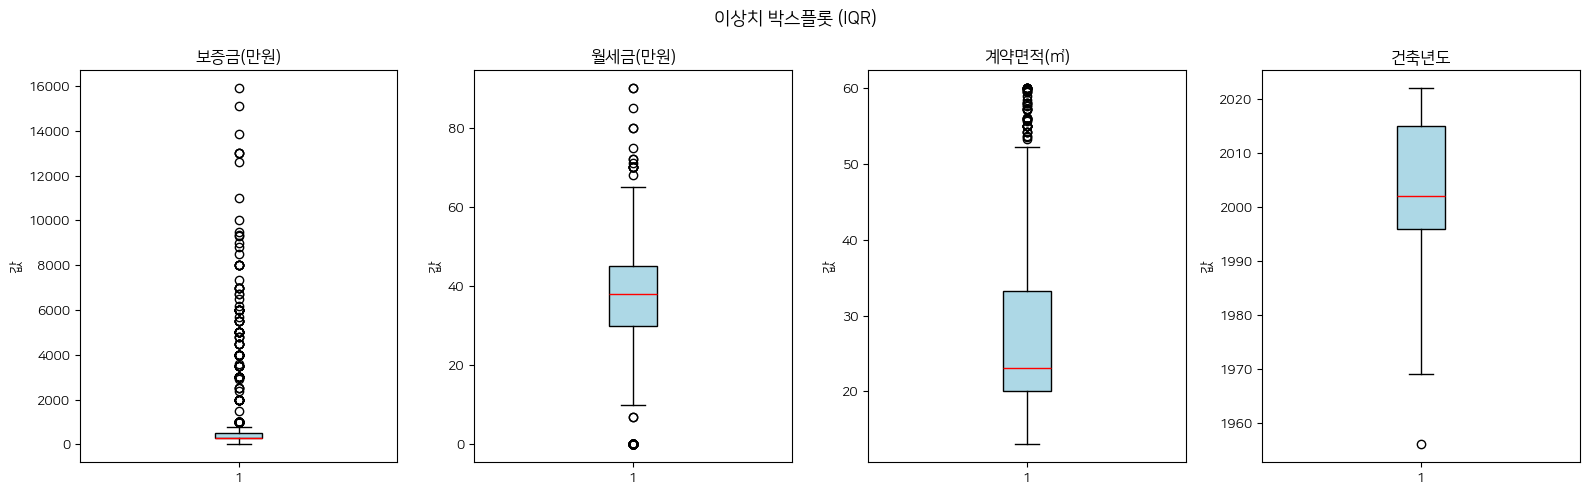

In [35]:
outlier_cols = ['보증금(만원)', '월세금(만원)', '계약면적(㎡)', '건축년도']

# IQR 방식 이상치 탐지
print("[IQR 기반 이상치 현황]")
outlier_summary = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'컬럼': col, 'Q1': q1, 'Q3': q3, '하한': lower, '상한': upper, '이상치 수': n_out, '이상치 비율(%)': round(n_out/len(df)*100, 2)})

display(pd.DataFrame(outlier_summary).set_index('컬럼'))

# 박스플롯
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
    ax.set_title(col)
    ax.set_ylabel('값')
plt.suptitle('이상치 박스플롯 (IQR)', fontsize=13)
plt.tight_layout()
plt.show()

## STEP 5: 선형/비선형 특성 판단

In [36]:
from scipy import stats

linear_cols = ['계약면적(㎡)', '보증금(만원)', '건축년도']

print("[피어슨 상관계수 & Spearman 상관계수 비교]")
print(f"{'Feature':<15} {'Pearson r':>10} {'Spearman r':>12} {'판단':>12}")
print("-" * 52)
results = []
for col in linear_cols:
    sub = df[[col, TARGET]].dropna()
    pearson_r, _ = stats.pearsonr(sub[col], sub[TARGET])
    spearman_r, _ = stats.spearmanr(sub[col], sub[TARGET])
    diff = abs(abs(pearson_r) - abs(spearman_r))
    judgment = "선형" if diff < 0.05 else "비선형"
    results.append({'feature': col, 'pearson': pearson_r, 'spearman': spearman_r, 'judgment': judgment})
    print(f"{col:<15} {pearson_r:>10.3f} {spearman_r:>12.3f} {judgment:>12}")

[피어슨 상관계수 & Spearman 상관계수 비교]
Feature          Pearson r   Spearman r           판단
----------------------------------------------------
계약면적(㎡)              0.066        0.156          비선형
보증금(만원)             -0.661       -0.078          비선형
건축년도                 0.212        0.236           선형


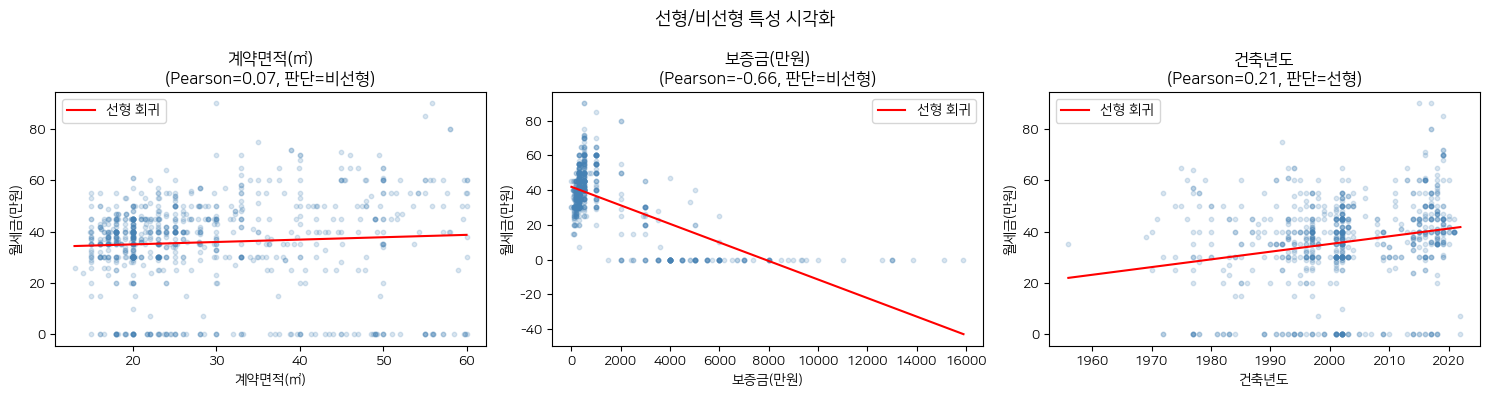


[모델 선택 근거 요약]
비선형 특성 feature: ['계약면적(㎡)', '보증금(만원)']
→ 비선형 모델(Random Forest, XGBoost 등) 또는 feature 변환(로그, 다항) 고려


In [37]:
# 회귀선 포함 산점도 (선형/비선형 시각적 확인)
fig, axes = plt.subplots(1, len(linear_cols), figsize=(15, 4))
for ax, col in zip(axes, linear_cols):
    sub = df[[col, TARGET]].dropna()
    ax.scatter(sub[col], sub[TARGET], alpha=0.2, s=10, color='steelblue')
    # 선형 회귀선
    m, b = np.polyfit(sub[col], sub[TARGET], 1)
    x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label='선형 회귀')
    r = next(item for item in results if item['feature'] == col)
    ax.set_title(f"{col}\n(Pearson={r['pearson']:.2f}, 판단={r['judgment']})")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.legend()
plt.suptitle('선형/비선형 특성 시각화', fontsize=13)
plt.tight_layout()
plt.show()

print("\n[모델 선택 근거 요약]")
linear_feats = [r['feature'] for r in results if r['judgment'] == '선형']
nonlinear_feats = [r['feature'] for r in results if r['judgment'] == '비선형']
if nonlinear_feats:
    print(f"비선형 특성 feature: {nonlinear_feats}")
    print("→ 비선형 모델(Random Forest, XGBoost 등) 또는 feature 변환(로그, 다항) 고려")
else:
    print(f"전체 feature가 선형 특성 → 선형 회귀 모델 우선 시도 가능")

## 데이터 전처리

In [38]:
df_pre = pd.read_csv('data/rent_merged.csv', encoding='utf-8-sig')

# 숫자형 변환
for col in ['보증금(만원)', '월세금(만원)', '종전계약 보증금(만원)', '종전계약 월세(만원)']:
    if col in df_pre.columns:
        df_pre[col] = df_pre[col].astype(str).str.replace(',', '')
        df_pre[col] = pd.to_numeric(df_pre[col], errors='coerce')
df_pre['계약면적(㎡)'] = pd.to_numeric(df_pre['계약면적(㎡)'], errors='coerce')
df_pre['건축년도'] = pd.to_numeric(df_pre['건축년도'], errors='coerce')

# 컬럼 삭제
drop_cols = ['NO', '시군구', '번지', '갱신요구권 사용', '종전계약 보증금(만원)',
             '종전계약 월세(만원)', '계약년월', '계약일', '주택유형', '계약구분', '도로명']
df_pre = df_pre.drop(columns=drop_cols)

# 전세 데이터 삭제
before = len(df_pre)
df_pre = df_pre[df_pre['전월세구분'] == '월세'].drop(columns=['전월세구분'])
print(f"전세 삭제: {before}행 → {len(df_pre)}행 (삭제 {before - len(df_pre)}개)")
print(f"\n남은 컬럼: {df_pre.columns.tolist()}")
df_pre.head(3)

전세 삭제: 873행 → 768행 (삭제 105개)

남은 컬럼: ['도로조건', '계약면적(㎡)', '보증금(만원)', '월세금(만원)', '건축년도', '계약기간']


,도로조건,계약면적(㎡),보증금(만원),월세금(만원),건축년도,계약기간
0,25m미만,23.0,500,45,2021.0,202604~202704
1,8m미만,17.0,300,45,NaN,202604~202612
2,8m미만,20.0,300,45,2016.0,202604~202704


In [39]:
# 건축년도 결측치 → 중앙값 대체
median_year = df_pre['건축년도'].median()
missing_cnt = df_pre['건축년도'].isna().sum()
df_pre['건축년도'] = df_pre['건축년도'].fillna(median_year)
print(f"건축년도 결측치 {missing_cnt}개 → 중앙값 {median_year}으로 대체")

# 계약기간 → 개월 수 변환 (예: 202504~202604 → 12)
def period_to_months(period):
    try:
        start, end = str(period).split('~')
        sy, sm = int(start.strip()[:4]), int(start.strip()[4:])
        ey, em = int(end.strip()[:4]), int(end.strip()[4:])
        return (ey - sy) * 12 + (em - sm)
    except:
        return None

df_pre['계약기간'] = df_pre['계약기간'].apply(period_to_months)
print(f"\n계약기간 변환 결과:\n{df_pre['계약기간'].value_counts().sort_index()}")

# 계약기간 결측치 → 최빈값 대체
mode_period = int(df_pre['계약기간'].mode()[0])
missing_cnt = df_pre['계약기간'].isna().sum()
df_pre['계약기간'] = df_pre['계약기간'].fillna(mode_period)
print(f"\n계약기간 결측치 {missing_cnt}개 → 최빈값 {mode_period}개월로 대체")

건축년도 결측치 59개 → 중앙값 2002.0으로 대체

계약기간 변환 결과:
계약기간
3.0       1
4.0       4
5.0       5
6.0      18
7.0       1
8.0       3
9.0       6
10.0      9
11.0     70
12.0    421
13.0      7
14.0      2
16.0      1
17.0      2
18.0      2
19.0      1
20.0      1
22.0      2
23.0     13
24.0    155
48.0      2
Name: count, dtype: int64

계약기간 결측치 42개 → 최빈값 12개월로 대체


In [40]:
# 도로조건 원핫인코딩
print(f"도로조건 고유값: {df_pre['도로조건'].value_counts().to_dict()}")
df_pre = pd.get_dummies(df_pre, columns=['도로조건'], prefix='도로조건', dtype=int)

print(f"\n원핫인코딩 후 컬럼: {df_pre.columns.tolist()}")
print(f"\n최종 shape: {df_pre.shape}")
df_pre.head(3)

도로조건 고유값: {'8m미만': 406, '12m미만': 296, '25m미만': 42, '25m이상': 23, '-': 1}

원핫인코딩 후 컬럼: ['계약면적(㎡)', '보증금(만원)', '월세금(만원)', '건축년도', '계약기간', '도로조건_-', '도로조건_12m미만', '도로조건_25m미만', '도로조건_25m이상', '도로조건_8m미만']

최종 shape: (768, 10)


,계약면적(㎡),보증금(만원),월세금(만원),건축년도,계약기간,도로조건_-,도로조건_12m미만,도로조건_25m미만,도로조건_25m이상,도로조건_8m미만
0,23.0,500,45,2021.0,12.0,0,0,1,0,0
1,17.0,300,45,2002.0,8.0,0,0,0,0,1
2,20.0,300,45,2016.0,12.0,0,0,0,0,1


In [41]:
import os
os.makedirs('preprocess', exist_ok=True)
df_pre.to_csv('preprocess/rent_preprocessed.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: preprocess/rent_preprocessed.csv")
print(f"최종 데이터: {df_pre.shape[0]}행 × {df_pre.shape[1]}열")
print(f"\n결측치 잔여:\n{df_pre.isnull().sum()[df_pre.isnull().sum() > 0]}")

저장 완료: preprocess/rent_preprocessed.csv
최종 데이터: 768행 × 10열

결측치 잔여:
Series([], dtype: int64)


## 모델링 - Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 데이터 로드
df_model = pd.read_csv('preprocess/rent_preprocessed.csv', encoding='utf-8-sig')

TARGET = '월세금(만원)'
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# 7:3 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"전체 샘플: {len(df_model)}개")
print(f"학습셋:   {len(X_train)}개")
print(f"테스트셋: {len(X_test)}개")
print(f"\nFeature 수: {X.shape[1]}개")
print(X.columns.tolist())

전체 샘플: 768개
학습셋:   537개
테스트셋: 231개

Feature 수: 9개
['계약면적(㎡)', '보증금(만원)', '건축년도', '계약기간', '도로조건_-', '도로조건_12m미만', '도로조건_25m미만', '도로조건_25m이상', '도로조건_8m미만']


In [43]:
# 모델 학습
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# 성능 지표
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 35)
print("       Random Forest 성능")
print("=" * 35)
print(f"  R²   (설명력):  {r2:.4f}")
print(f"  RMSE (오차):    {rmse:.2f} 만원")
print(f"  MAE  (오차):    {mae:.2f} 만원")
print("=" * 35)

       Random Forest 성능
  R²   (설명력):  0.3747
  RMSE (오차):    8.36 만원
  MAE  (오차):    6.19 만원


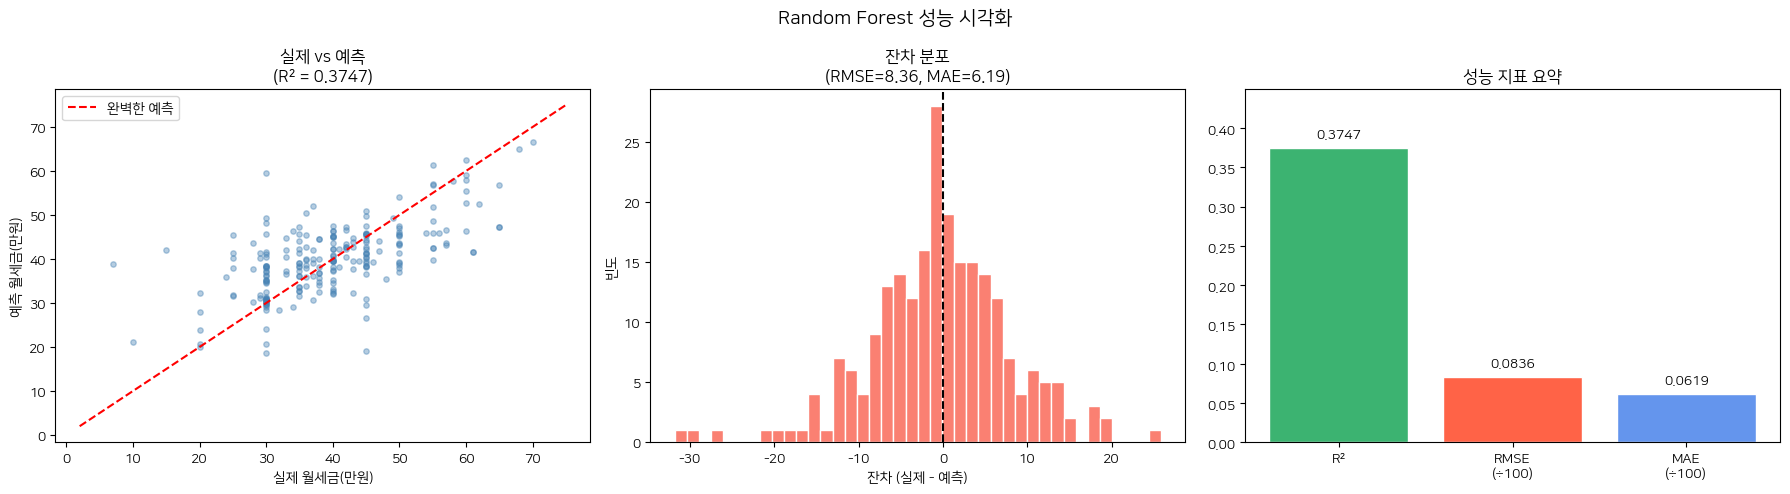

In [44]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 실제 vs 예측 산점도
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lim = [min(y_test.min(), y_pred.min()) - 5, max(y_test.max(), y_pred.max()) + 5]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='완벽한 예측')
ax.set_xlabel('실제 월세금(만원)')
ax.set_ylabel('예측 월세금(만원)')
ax.set_title(f'실제 vs 예측\n(R² = {r2:.4f})')
ax.legend()

# 2) 잔차 분포
ax = axes[1]
residuals = y_test.values - y_pred
ax.hist(residuals, bins=40, edgecolor='white', color='salmon')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('잔차 (실제 - 예측)')
ax.set_ylabel('빈도')
ax.set_title(f'잔차 분포\n(RMSE={rmse:.2f}, MAE={mae:.2f})')

# 3) 성능 지표 바 차트
ax = axes[2]
metrics = {'R²': r2, 'RMSE\n(÷100)': rmse / 100, 'MAE\n(÷100)': mae / 100}
colors = ['mediumseagreen', 'tomato', 'cornflowerblue']
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_title('성능 지표 요약')
ax.set_ylim(0, max(metrics.values()) * 1.2)

plt.suptitle('Random Forest 성능 시각화', fontsize=14)
plt.tight_layout()
plt.show()

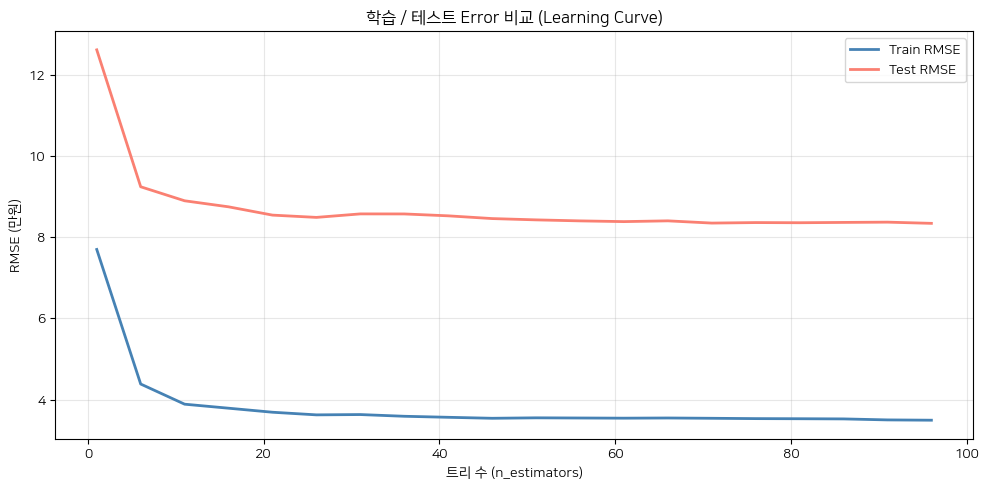

Test RMSE 최소: 8.34 만원  (트리 수 = 96)


In [45]:
# 트리 수에 따른 Train / Test Error 변화 (Learning Curve)
n_range = list(range(1, 101, 5))
train_errors, test_errors = [], []

for n in n_range:
    rf_tmp = RandomForestRegressor(n_estimators=n, random_state=42)
    rf_tmp.fit(X_train, y_train)
    train_errors.append(mean_squared_error(y_train, rf_tmp.predict(X_train)) ** 0.5)
    test_errors.append(mean_squared_error(y_test,  rf_tmp.predict(X_test))  ** 0.5)

plt.figure(figsize=(10, 5))
plt.plot(n_range, train_errors, label='Train RMSE', color='steelblue',  linewidth=2)
plt.plot(n_range, test_errors,  label='Test RMSE',  color='salmon', linewidth=2)
plt.xlabel('트리 수 (n_estimators)')
plt.ylabel('RMSE (만원)')
plt.title('학습 / 테스트 Error 비교 (Learning Curve)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n = n_range[int(np.argmin(test_errors))]
print(f"Test RMSE 최소: {min(test_errors):.2f} 만원  (트리 수 = {best_n})")

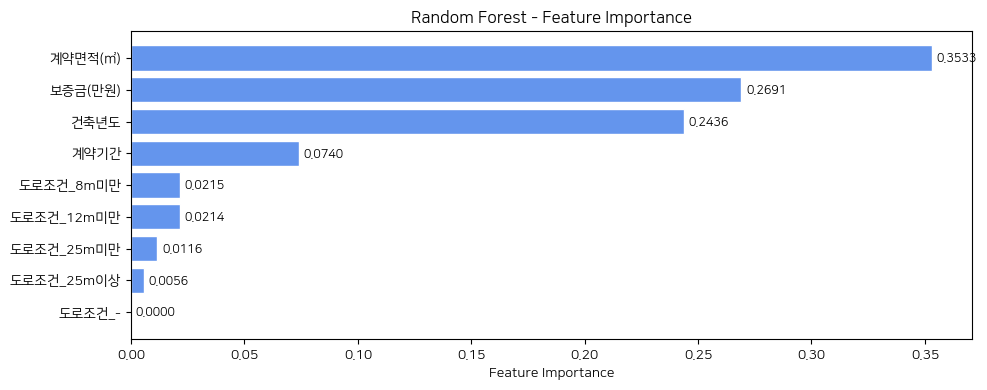


[Feature Importance 순위]
계약면적(㎡)       0.353263
보증금(만원)       0.269083
건축년도          0.243566
계약기간          0.073976
도로조건_8m미만     0.021470
도로조건_12m미만    0.021441
도로조건_25m미만    0.011630
도로조건_25m이상    0.005571
도로조건_-        0.000000


In [46]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, max(4, len(importances) * 0.4)))
bars = plt.barh(importances.index, importances.values, color='cornflowerblue', edgecolor='white')
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Feature Importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("\n[Feature Importance 순위]")
print(importances.sort_values(ascending=False).to_string())

## 모델링 - 도로조건 제외 + 신축/구축 이진 변환

사용 Feature: ['계약면적(㎡)', '보증금(만원)', '건축년도', '계약기간']
제외된 도로조건 컬럼: ['도로조건_-', '도로조건_12m미만', '도로조건_25m미만', '도로조건_25m이상', '도로조건_8m미만']

  Random Forest 성능 (도로조건 제외)
  R²   (설명력):  0.3488
  RMSE (오차):    8.53 만원
  MAE  (오차):    6.38 만원


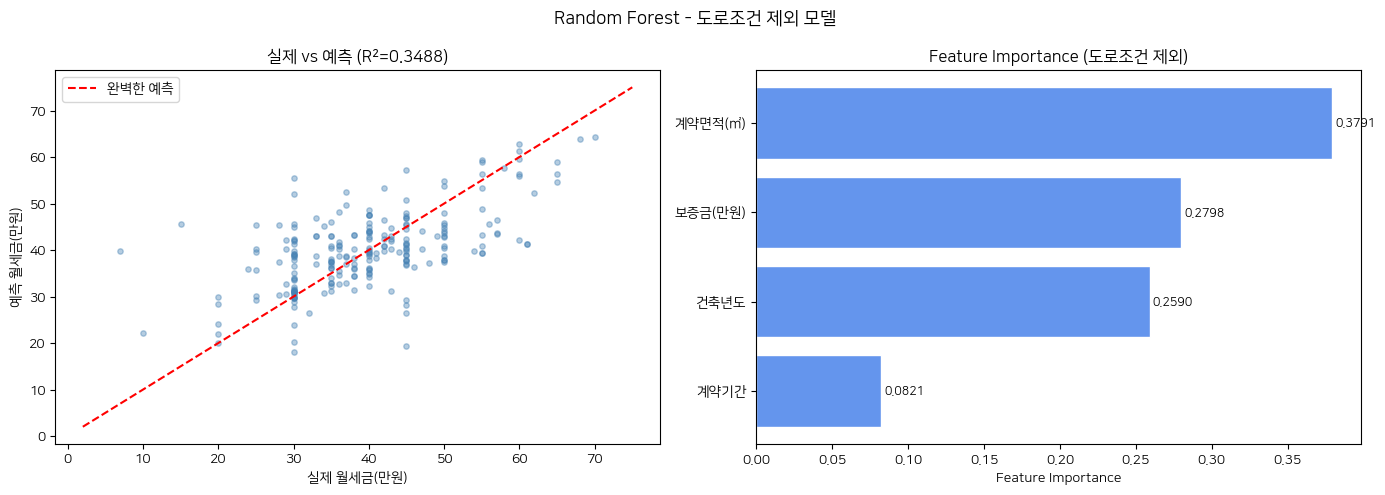

In [47]:
# 도로조건 관련 컬럼 제외 (건축년도는 수치형 그대로 유지)
road_cols = [c for c in df_model.columns if c.startswith('도로조건')]

df_model2 = df_model.drop(columns=road_cols).copy()

TARGET = '월세금(만원)'
X2 = df_model2.drop(columns=[TARGET])
y2 = df_model2[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

print(f"사용 Feature: {X2.columns.tolist()}")
print(f"제외된 도로조건 컬럼: {road_cols}")

# 학습
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)
y2_pred = rf2.predict(X2_test)

rmse2 = mean_squared_error(y2_test, y2_pred) ** 0.5
mae2  = mean_absolute_error(y2_test, y2_pred)
r2_2  = r2_score(y2_test, y2_pred)

print("\n" + "=" * 40)
print("  Random Forest 성능 (도로조건 제외)")
print("=" * 40)
print(f"  R²   (설명력):  {r2_2:.4f}")
print(f"  RMSE (오차):    {rmse2:.2f} 만원")
print(f"  MAE  (오차):    {mae2:.2f} 만원")
print("=" * 40)

# 성능 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y2_test, y2_pred, alpha=0.4, s=15, color='steelblue')
lim = [min(y2_test.min(), y2_pred.min()) - 5, max(y2_test.max(), y2_pred.max()) + 5]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='완벽한 예측')
ax.set_xlabel('실제 월세금(만원)')
ax.set_ylabel('예측 월세금(만원)')
ax.set_title(f'실제 vs 예측 (R²={r2_2:.4f})')
ax.legend()

ax = axes[1]
imp2 = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=True)
ax.barh(imp2.index, imp2.values, color='cornflowerblue', edgecolor='white')
for i, (idx, val) in enumerate(imp2.items()):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance (도로조건 제외)')

plt.suptitle('Random Forest - 도로조건 제외 모델', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def predict_rent(계약면적, 보증금, 건축년도, 계약기간):

    input_df = pd.DataFrame([[계약면적, 보증금, 건축년도, 계약기간]],
                             columns=['계약면적(㎡)', '보증금(만원)', '건축년도', '계약기간'])
    input_df = input_df[X2.columns]

    pred = rf2.predict(input_df)[0]

    print("=" * 35)
    print("       예측 월세 결과")
    print("=" * 35)
    print(f"  계약면적  : {계약면적} ㎡")
    print(f"  보증금    : {보증금:,} 만원")
    print(f"  건축년도  : {건축년도} (건축년도 ≈ {건축년도})")
    print(f"  계약기간  : {계약기간} 개월")
    print("-" * 35)
    print(f"  예측 월세 : {pred:.1f} 만원")
    print("=" * 35)
    return pred

# 사용자 입력
print("=== 월세 예측기 ===")
계약면적 = float(input("계약면적 (㎡): "))
보증금   = float(input("보증금 (만원): "))
건축년도 = input("건축년도: ").strip()
계약기간 = int(input("계약기간 (개월): "))

predict_rent(계약면적, 보증금, 건축년도, 계약기간)

=== 월세 예측기 ===


ValueError: 건축구분은 '신축' 또는 '구축'만 입력 가능합니다.